# Decompose the CO₂ levers of action into sub-levers

AeroMAPS expresses the reduction of CO₂ emissions with respect to a frozen-technology trajectory as a cascade of levers of action: demand, aircraft efficiency, operations and load factor, aircraft energy, and carbon offsetting. The `air_transport_co2_emissions` plot draws them as wedges.

This tutorial shows how to split some of these wedges into sub-wedges:

- the **aircraft efficiency** wedge per aircraft of the fleet (bottom-up fleet model),
- the **aircraft energy** wedge per energy pathway (generic energy models),
- **every** wedge per market.

Each decomposition is exact by construction: the sub-wedges, including an explicit residual, sum to the wedge they split.

The scenario is the one of the fleet tutorial (default markets, fleet and energy carriers), with one addition. The recent reference aircraft improve by 10 % between 2020 and 2050 through the `continuous_improvement_factor_energy` field of `data/aircraft_inventory.yaml`, so that the corresponding sub-wedge is visible.

## Load and compute

The three decomposition models (`DetailedCo2EmissionsPerAircraft`, `DetailedCo2EmissionsPerPathway`, `DetailedCo2EmissionsPerMarket`) are registered with the bottom-up efficiency and generic energy standards, so nothing has to be added to the configuration.

In [1]:
from aeromaps import create_process

process = create_process(configuration_file="data/config.yaml")
process.compute()
process.write_json()

## The aggregated wedges

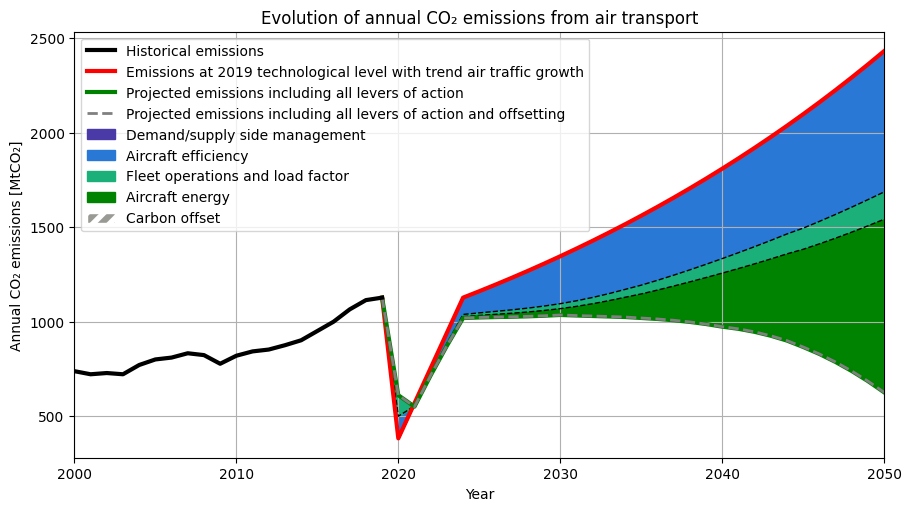

In [2]:
process.plot("air_transport_co2_emissions", save=False)

## Aircraft efficiency per aircraft, aircraft energy per pathway

`air_transport_co2_emissions_detailed` replaces the efficiency and energy wedges by their sub-wedges. When a decomposition is not available (top-down fleet, or non-generic energy models), the corresponding wedge falls back to a single band.

Efficiency sub-wedges (`DetailedCo2EmissionsPerAircraft`):

- **Fleet renewal**: replacement of the old reference aircraft by the recent one, without any new aircraft.
- **Continuous improvement**: drift of the recent reference aircraft itself when a `continuous_improvement_factor_energy` is set.
- **One band per new aircraft**: its additional gain beyond fleet renewal, weighted by the share of the market it serves.
- **Freight fleet**: the freight efficiency, which has no bottom-up fleet.
- **Traffic mix**: the effect of the changing split of ASK between markets. It can be negative when the most energy-intensive markets grow faster.

Energy sub-wedges (`DetailedCo2EmissionsPerPathway`): each pathway is credited with its energy consumption times the gap between the reference-year mean carbon intensity and its own. The reference is the mean carbon intensity of the reference year, not that of fossil kerosene. Here they coincide, so fossil kerosene has no band; in a scenario where low-carbon fuels are already used in the reference year, fossil kerosene shows a small negative band as long as some of it remains.

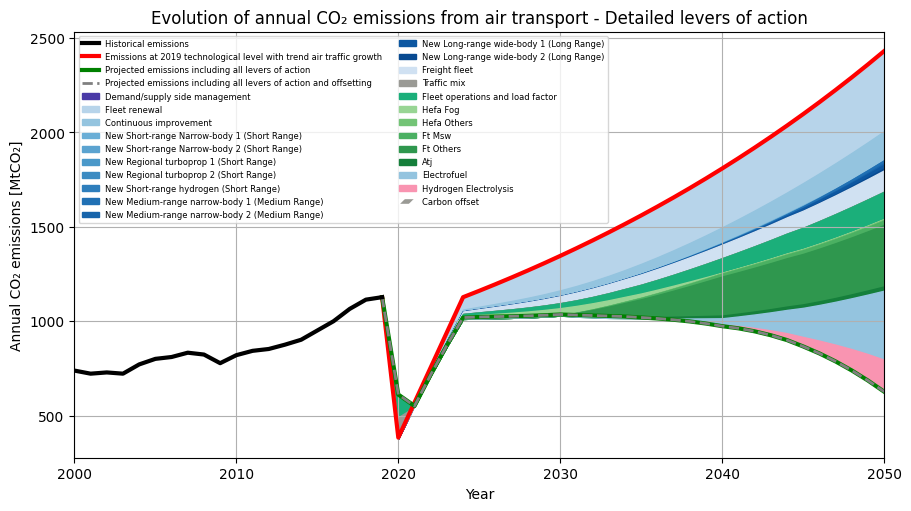

In [3]:
process.plot("air_transport_co2_emissions_detailed", save=False)

### Coarser granularity

The same plot accepts `efficiency_granularity="category"` (one band per fleet category) and `energy_granularity="family"` (biofuels, electrofuels, fossil-derived, hydrogen, electric). `air_transport_co2_emissions_grouped` is the shortcut for both.

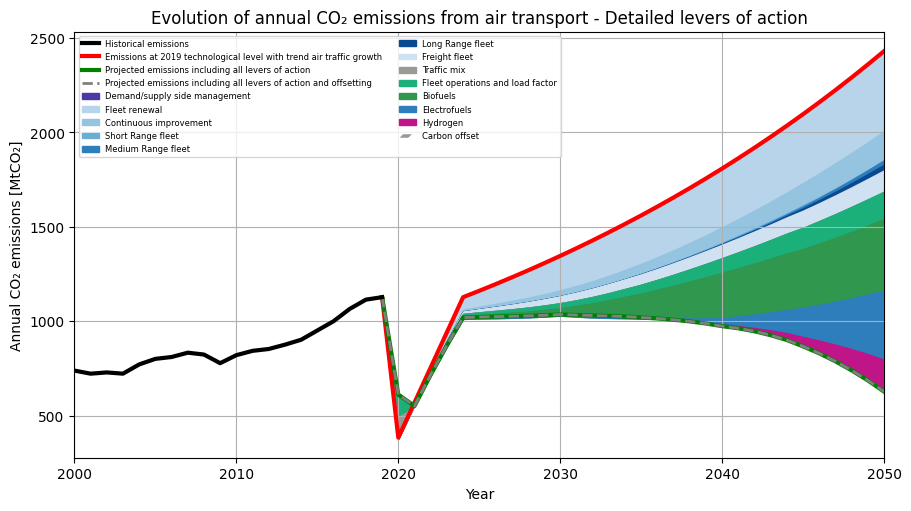

In [4]:
process.plot("air_transport_co2_emissions_grouped", save=False)

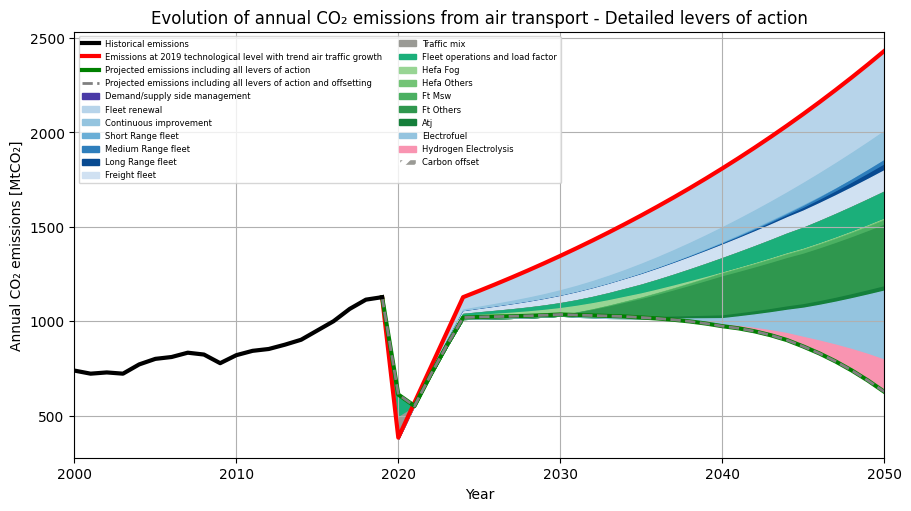

In [5]:
process.plot(
    "air_transport_co2_emissions_detailed",
    save=False,
    efficiency_granularity="category",
    energy_granularity="pathway",
)

## Every wedge per market

`DetailedCo2EmissionsPerMarket` recomputes the cascade for each passenger and freight market with its own traffic and energy intensities. The global cascade uses fleet-wide means, so the sum over markets differs from the global wedge by a cross-market-mix term, which is reported explicitly. Several per-market contributions change sign over time, so the plot uses one panel per lever with signed lines rather than a stacked chart.

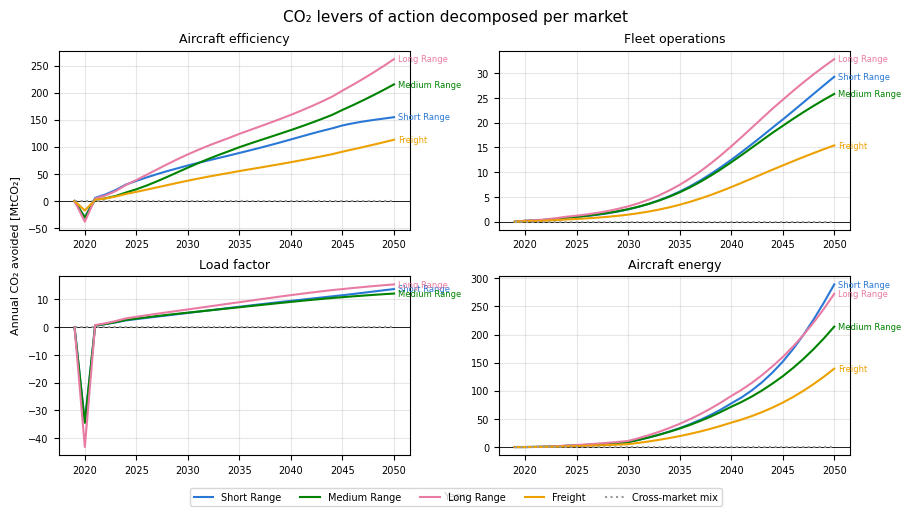

In [6]:
process.plot("air_transport_co2_emissions_per_market", save=False)

The per-market columns are exposed through a tidy accessor with a `(lever, market)` column index.

In [7]:
from aeromaps.models.impacts.emissions.co2_emissions import market_lever_dataframe

vector = process.data["vector_outputs"]
per_market = market_lever_dataframe(vector, process.markets)
per_market.loc[[2030, 2040, 2050]].round(1)

lever,efficiency,operations,loadfactor,energy,efficiency,operations,loadfactor,energy,efficiency,operations,loadfactor,energy,efficiency,operations,energy,efficiency,operations,loadfactor,energy
market,short_range,short_range,short_range,short_range,medium_range,medium_range,medium_range,medium_range,long_range,long_range,long_range,long_range,freight,freight,freight,cross_mix,cross_mix,cross_mix,cross_mix
2030,65.6,2.5,5.1,8.7,61.6,2.5,5.2,8.9,86.1,3.1,6.4,10.9,37.5,1.4,5.1,0.0,0.0,0.0,0.0
2040,113.6,12.5,9.5,77.5,131.0,12.0,9.1,71.6,159.1,15.2,11.5,90.8,71.6,7.0,43.4,0.0,0.0,0.0,0.0
2050,154.7,29.3,13.7,289.2,215.3,25.8,12.1,214.2,261.9,32.8,15.4,272.5,113.1,15.4,139.4,0.0,0.0,0.0,0.0


In [8]:
per_market.xs("energy", level="lever", axis=1).loc[[2030, 2040, 2050]].round(1)

market,short_range,medium_range,long_range,freight,cross_mix
2030,8.7,8.9,10.9,5.1,0.0
2040,77.5,71.6,90.8,43.4,0.0
2050,289.2,214.2,272.5,139.4,0.0


## Sub-wedge values

The sub-wedges are ordinary output columns, in MtCO₂ avoided with respect to the frozen-technology trajectory.

In [9]:
from aeromaps.models.impacts.emissions.co2_emissions import market_lever_names

market_columns = set(market_lever_names(process.markets).values())


def sub_levers(prefix):
    return [c for c in vector.columns if c.startswith(prefix) and c not in market_columns]


vector.loc[[2030, 2040, 2050], sub_levers("co2_emissions_lever_efficiency_")].round(1).T

,2030,2040,2050
co2_emissions_lever_efficiency_short_range_new_short_range_narrow_body_1,0.0,2.5,6.0
co2_emissions_lever_efficiency_short_range_new_short_range_narrow_body_2,0.0,0.0,3.5
co2_emissions_lever_efficiency_short_range_new_regional_turboprop_1,0.3,4.9,12.8
co2_emissions_lever_efficiency_short_range_new_regional_turboprop_2,0.0,0.0,3.4
co2_emissions_lever_efficiency_short_range_new_short_range_hydrogen,0.0,-2.8,-35.6
co2_emissions_lever_efficiency_medium_range_new_medium_range_narrow_body_1,0.0,2.7,14.7
co2_emissions_lever_efficiency_medium_range_new_medium_range_narrow_body_2,0.0,0.0,8.7
co2_emissions_lever_efficiency_long_range_new_long_range_wide_body_1,0.0,3.4,18.8
co2_emissions_lever_efficiency_long_range_new_long_range_wide_body_2,0.0,0.0,11.1
co2_emissions_lever_efficiency_fleet_renewal,182.6,311.6,424.2


In [10]:
vector.loc[[2030, 2040, 2050], sub_levers("co2_emissions_lever_energy_")].round(1).T

,2030,2040,2050
co2_emissions_lever_energy_hefa_fog,39.3,1.6,2.5
co2_emissions_lever_energy_hefa_others,0.0,3.5,5.5
co2_emissions_lever_energy_ft_msw,0.0,15.2,23.8
co2_emissions_lever_energy_ft_others,0.0,206.8,325.6
co2_emissions_lever_energy_atj,0.0,14.4,22.7
co2_emissions_lever_energy_electrofuel,-5.8,33.7,365.9
co2_emissions_lever_energy_fossil_kerosene,0.0,0.0,0.0
co2_emissions_lever_energy_hydrogen_electrolysis,0.0,8.0,169.3
co2_emissions_lever_energy_hydrogen_gas,0.0,0.0,0.0
co2_emissions_lever_energy_hydrogen_gas_ccs,0.0,0.0,0.0


## Check that the decompositions are exact

Each set of sub-wedges sums to the wedge it splits. The residuals below are floating-point noise only.

In [11]:
years = range(process.parameters.prospection_start_year, process.parameters.end_year + 1)

cascade = {
    "efficiency": (
        "co2_emissions_last_historical_year_technology",
        "co2_emissions_including_aircraft_efficiency",
    ),
    "operations": ("co2_emissions_including_aircraft_efficiency", "co2_emissions_including_operations"),
    "loadfactor": ("co2_emissions_including_operations", "co2_emissions_including_load_factor"),
    "energy": ("co2_emissions_including_load_factor", "co2_emissions_including_energy"),
}


def wedge(lever):
    upper, lower = cascade[lever]
    return (vector[upper] - vector[lower]).loc[years]


def residual(lever, sub_wedges):
    return float((wedge(lever) - sub_wedges.loc[years].sum(axis=1)).abs().max())


print("efficiency per aircraft:", residual("efficiency", vector[sub_levers("co2_emissions_lever_efficiency_")]))
print("energy per pathway:    ", residual("energy", vector[sub_levers("co2_emissions_lever_energy_")]))
for lever in cascade:
    print(f"{lever} per market:".ljust(24), residual(lever, per_market.xs(lever, level="lever", axis=1)))

efficiency per aircraft: 1.2505552149377763e-12
energy per pathway:     8.526512829121202e-13
efficiency per market:   7.958078640513122e-13
operations per market:   5.968558980384842e-13
loadfactor per market:   2.8421709430404007e-13
energy per market:       3.979039320256561e-13


In [12]:
# Verify the outputs between .outputs.json and data/reference/outputs.json
from aeromaps.utils.functions import compare_json_files

files_are_different = compare_json_files(
    "./data/reference/outputs.json",
    "./data/outputs.json",
    rtol=0.0001,
    atol=0,
)

if files_are_different:
    raise ValueError("The outputs.json files are different.")

No differences found.


In [13]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())